# Runge function with Pytorch

In [1]:
from source.runge_preprocessing import activations, activations_derivative, _dim, x_train_scaled, y_train, x_test, x_train, x_test_scaled, x, y


REMEMBER TO GIVE REFERENCES TO COPILOT JUPYER FILE, BOTH FOR REGRESSION AND COST FUNCTIONS
Modellen er trent og resultatet er lagret i poly_regression.png.


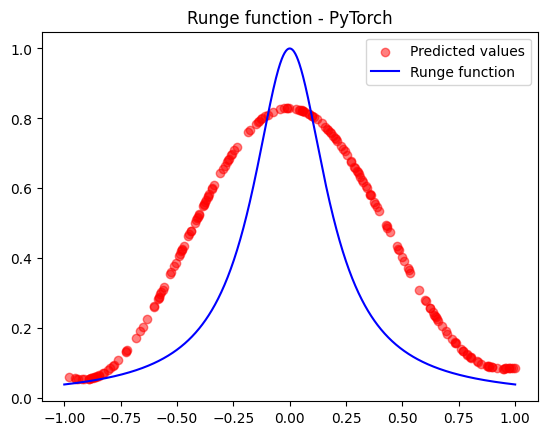

In [2]:

print('REMEMBER TO GIVE REFERENCES TO COPILOT JUPYER FILE, BOTH FOR REGRESSION AND COST FUNCTIONS')

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Sett seed for reproduserbarhet
torch.manual_seed(0)


x_train_scaled_tensor = torch.from_numpy(x_train_scaled).float()  
y_train_tensor = torch.from_numpy(y_train).float()     

x_test_tensor = torch.from_numpy(x_test).float()     

poly_degree = 15
# Lag polynomfunksjoner
def make_poly_features(x, poly_degree):
    return torch.cat([x**i for i in range(1, poly_degree + 1)], dim=1)

x_poly = make_poly_features(x_train_scaled_tensor, poly_degree)
x_test_poly = make_poly_features(x_test_tensor, poly_degree)#, include_bias=True)

# Definer modell
model = nn.Linear(poly_degree, 1)

# Tapfunksjon og optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Tren modellen
iterations = 100000
for epoch in range(iterations):
    model.train()
    y_pred = model(x_poly)
    loss = criterion(y_pred, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Visualiser resultatet
with torch.no_grad():
    y_fit = model(x_test_poly)


plt.scatter(x_test, y_fit.numpy(), color='red', label='Predicted values', alpha=0.5)
plt.plot(x, y, color='blue', label='Runge function')
plt.legend()
plt.title('Runge function - PyTorch')
#plt.savefig("poly_regression.png")

print("Modellen er trent og resultatet er lagret i poly_regression.png.")

# Comparing gradients from own implementation and autograd

In [3]:
# custom imports
from source.neural_network import NN

In [4]:
import source.schedulers as schedulers
from source.runge_preprocessing import x_test, y_test

runge_NN = NN(dims = _dim, activation_funcs = activations, activation_ders = activations_derivative)
runge_NN.compare_gradients(X = x_train_scaled, targets = y_train)




Compare gradients between own and autograd calculations:
Layer 0: dW match: True, db match: True
Layer 1: dW match: True, db match: True
Layer 2: dW match: True, db match: True

Differences between own and autograd gradients
Layer 0 - dW diff:
[[ 4.33680869e-19  1.08420217e-19  0.00000000e+00 -4.33680869e-19
   0.00000000e+00 -1.08420217e-19  2.71050543e-20 -8.67361738e-19
  -8.67361738e-19  0.00000000e+00  1.73472348e-18  1.08420217e-19
   4.33680869e-19  0.00000000e+00 -4.33680869e-19  0.00000000e+00
   0.00000000e+00  0.00000000e+00  8.67361738e-19  0.00000000e+00
   4.33680869e-19 -5.42101086e-20 -2.16840434e-19 -2.16840434e-19
   8.67361738e-19 -4.33680869e-19  4.33680869e-19  1.08420217e-19
  -4.33680869e-19  8.67361738e-19 -3.79470760e-19  0.00000000e+00
  -2.16840434e-19 -8.13151629e-20 -5.42101086e-20  4.33680869e-19
   0.00000000e+00  4.33680869e-19  1.08420217e-19  0.00000000e+00
   1.08420217e-19  5.42101086e-20 -4.33680869e-19 -8.67361738e-19
   2.16840434e-19  6.77626358